<span style="color:red; font-family:Helvetica Neue, Helvetica, Arial, sans-serif; font-size:2em;">An Exception was encountered at '<a href="#papermill-error-cell">In [13]</a>'.</span>

## **Import libraries**

In [ ]:
import os
import random
import asyncio

SEED = 8
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

import numpy as np
import pandas as pd

from natsort import natsorted
from collections import defaultdict

import torch
import torch.nn as nn
from transformers import set_seed as transformers_set_seed

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

def seed_everything(seed: int = SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    transformers_set_seed(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False
    torch.use_deterministic_algorithms(True)

seed_everything(SEED)

from SARVI.config import (
    paths
)
from SARVI.models.schemas import (
    PipelineContext,
    DOCXToJSONSConfig,
    LLMConfig
)
from SARVI.models.losses import (
    MoMLoss
)

from SARVI.data_io.reader import (
    textwrap,
    read_txt_list, read_ann_list,
    read_json_single,
    read_excel_single
)
from SARVI.data_io.writing import (
    write_torch_checkpoint, write_json_extra_docs, write_parquet
)

from SARVI.services.common.llm_loader import (
    load_llm
)
from SARVI.services.common.tree_funcs import (
    load_tree_hierarchical_module
)
from SARVI.services.common.llm_funcs import (
    prompts as prompts_total
)
from SARVI.services.common.ner_funcs import(
    tokenizer_ner, model_ner, initialize_span_ner_model, NER_WINDOW_LABELS
)
from SARVI.services.sync_funcs.ner_funcs import (
    prepare_data as prepare_data_SYNC,
    construct_loaders_ner as construct_loaders_ner_SYNC,
    run_span_nerclassifier as run_span_nerclassifier_SYNC
)

Some weights of XLMRobertaModel were not initialized from the model checkpoint at IIC/RigoBERTa-Clinical and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## **Initialize variables**

In [ ]:
def initialize_variables(ctx: PipelineContext):
    print("0. Initializing variables\n")
    # create_intermediate_folder_name(ctx)

    #################################################################################################################

    if ctx.cie_10_version == "2018":
        df_reference = read_excel_single(ctx, "Diagnosticos_ES2018.xlsx", sheet_name="finales", header=0)
        df_reference = df_reference[['codigo', 'descripcion']].reset_index(drop=True).rename(columns={'codigo': 'Código', 'descripcion': 'Descripción'})
        df_reference["Código"] = (df_reference["Código"].astype(str).str.strip().str.replace("\xa0", "", regex=False))
        df_reference = df_reference[df_reference["Código"].str.match(r"^[A-Za-z]\d[A-Za-z0-9](?:\.[A-Za-z0-9]+)?(?:-[A-Za-z]\d[A-Za-z0-9](?:\.[A-Za-z0-9]+)?)?$")]

    elif ctx.cie_10_version == "2024":
        df_reference = read_excel_single(ctx, "Diagnosticos_ES2024.xlsx", sheet_name="ES2024 Completa + Marcadores", header=0)
        df_reference = df_reference[["Código", "Descripción"]].reset_index(drop=True)
        df_reference["Código"] = (df_reference["Código"].astype(str).str.strip().str.replace("\xa0", "", regex=False))
        df_reference = df_reference[df_reference["Código"].str.match(r"^[A-Za-z]\d[A-Za-z0-9](?:\.[A-Za-z0-9]+)?(?:-[A-Za-z]\d[A-Za-z0-9](?:\.[A-Za-z0-9]+)?)?$")]

    else:
        df_reference = read_excel_single(ctx, "Diagnosticos_ES2026.xlsx", sheet_name="ES2026 Completa + Marcadores", header=0)
        df_reference = df_reference[["Código", "Descripción"]].reset_index(drop=True)
        df_reference["Código"] = (df_reference["Código"].astype(str).str.strip().str.replace("\xa0", "", regex=False))
        df_reference = df_reference[df_reference["Código"].str.match(r"^[A-Za-z]\d[A-Za-z0-9](?:\.[A-Za-z0-9]+)?(?:-[A-Za-z]\d[A-Za-z0-9](?:\.[A-Za-z0-9]+)?)?$")]

    #################################################################################################################

    report_list = natsorted(p for p in (ctx.paths.data_input / ctx.folder_and_archive_name).iterdir() if p.is_file())
    
    if ctx.ussage == "generative":
        llm = load_llm(ctx.llm_config)
        prompt = textwrap.dedent(prompts_total["report_to_data"])
        modelo_ner = None
        node_list = None
        modelo_icd10_head = None
        modelo_icd10_prediction = None
        label2id_ICD10 = None
        id2label_ICD10 = None
        id_no_hs_to_id_hs = None
        icd10_thresholds = None
    else:
        llm = None
        prompt = None
        modelo_ner = [None, None]
        node_list = load_tree_hierarchical_module(df_reference)

        root = node_list["root"]
        root.set_indexes()
        label2id_hs = {key.name: value for key, value in root.node_to_id.items()}
        id2label_hs = {value: key for key, value in label2id_hs.items()}
        label2id_no_hs = {id2label_hs[value.item()]: i for i, value in enumerate(root.leaf_indexes)}
        id2label_no_hs = {value: key for key, value in label2id_no_hs.items()}
        label2id_ICD10 = [label2id_hs, label2id_no_hs]
        id2label_ICD10 = [id2label_hs, id2label_no_hs]
        id_no_hs_to_id_hs = {id_no_hs: label2id_hs[label_name] for label_name, id_no_hs in label2id_no_hs.items()}

        # modelo_icd10_head = [initialize_icd10_hs_head_model(ctx, "ICD10_HS_checkpoint.pt", root), initialize_icd10_no_hs_head_model(ctx, "ICD10_NO_HS_checkpoint.pt", label2id_no_hs, root)]
        # modelo_icd10_prediction = [initialize_icd10_hs_prediction_model(ctx, "ICD10_HS_checkpoint.pt", label2id_hs, root), None]
        modelo_icd10_head = None
        modelo_icd10_prediction = None
        icd10_thresholds = read_json_single(ctx.paths.docs_dir / "thresholds_ICD10.json")
    
    semaforo = asyncio.Semaphore(ctx.MAX_CONCURRENCY)

    config = DOCXToJSONSConfig(
        report_list=report_list,
        prompt=prompt,
        llm=llm,
        semaforo=semaforo,
        modelo_ner=modelo_ner,
        node_list=node_list,
        modelo_icd10_head=modelo_icd10_head,
        modelo_icd10_prediction=modelo_icd10_prediction,
        label2id_ICD10=label2id_ICD10,
        id2label_ICD10=id2label_ICD10,
        id_no_hs_to_id_hs=id_no_hs_to_id_hs,
        icd10_thresholds=icd10_thresholds
    )

    return config

In [3]:
llm_config = LLMConfig(
    service="vllm",
    model="openai/gpt-oss-20b",
    device="cuda" if torch.cuda.is_available() else "cpu"
)

ctx = PipelineContext(
    ussage="deterministic",
    # folder_and_archive_name="E3C/train",
    folder_and_archive_name="E3C/train",
    llm_config=llm_config,
    paths=paths,
    cie_10_version="2026",
    json_parse=False,
    device = "cuda" if torch.cuda.is_available() else "cpu"
)

config = initialize_variables(ctx)

0. Initializing variables



Hierarchical tree construction: Cleaning data:   0%|          | 0/102426 [00:00<?, ?code/s]

## **Run SPAN NER data creation**

### **Create data**

In [4]:
print("1.1. Creating NER data // Train data")
dict_data_train = read_txt_list(ctx.paths.data_input / ctx.folder_and_archive_name)
df_data_train = pd.DataFrame(list(dict_data_train.items()), columns=["archivo_origen", "Text"])

dict_ann_train = read_ann_list(ctx.paths.data_input / ctx.folder_and_archive_name)
df_ann_train = pd.DataFrame([{"archivo_origen": file_name, **ann_data}for file_name, ann_data in dict_ann_train.items()])
# df_ann = None

data_prepared_train, all_window_labels_train, file_names_train = prepare_data_SYNC(df_data_train, data_ann=df_ann_train, padding=True, tokenizer=tokenizer_ner, model=model_ner, device=ctx.device, lemma=True)

print("1.1. Creating NER data // Dev data")
dict_data_dev = read_txt_list(ctx.paths.data_input / "E3C/dev")
df_data_dev = pd.DataFrame(list(dict_data_dev.items()), columns=["archivo_origen", "Text"])

dict_ann_dev = read_ann_list(ctx.paths.data_input / "E3C/dev")
df_ann_dev = pd.DataFrame([{"archivo_origen": file_name, **ann_data}for file_name, ann_data in dict_ann_dev.items()])
# df_ann = None

data_prepared_dev, all_window_labels_dev, file_names_dev = prepare_data_SYNC(df_data_dev, data_ann=df_ann_dev, padding=True, tokenizer=tokenizer_ner, model=model_ner, device=ctx.device, lemma=True)

1.1. Creating NER data // Train data


Preparing data for NER prediction: Window slicing and overlapping tokens:   0%|          | 0/48 [00:00<?, ?tex…

Token indices sequence length is longer than the specified maximum sequence length for this model (971 > 512). Running this sequence through the model will result in indexing errors


1.1. Creating NER data // Dev data


Preparing data for NER prediction: Window slicing and overlapping tokens:   0%|          | 0/16 [00:00<?, ?tex…

> Example of label output

In [5]:
all_window_labels_dev

[[['O',
   '1_B-LIVB',
   '1_I-LIVB',
   '1_I-LIVB',
   '1_I-LIVB',
   '1_I-LIVB',
   '1_I-LIVB',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   '2_B-DISO',
   '2_B-DISO',
   '2_B-DISO',
   'O',
   'O',
   'O',
   'O',
   '3_B-Date',
   '3_I-Date',
   'O',
   'O',
   'O',
   '4_B-DISO',
   '4_B-DISO',
   'O',
   'O',
   'O',
   'O',
   'O',
   '5_B-DISO',
   '5_B-DISO',
   '5_B-DISO',
   '5_B-DISO',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   '6_B-DISO',
   '6_B-DISO',
   '6_B-DISO',
   'O',
   'O',
   'O',
   '7_B-DISO',
   '7_B-DISO',
   '7_I-DISO',
   '7_I-DISO',
   '7_I-DISO',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   '8_B-DISO',
   '8_I-DISO',
   '8_I-DISO',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   '

In [6]:
### Example of labels
example_window_labels = all_window_labels_train[2][0]
example_data_prepared = data_prepared_train[2][0]["input_ids"]

for i,(label,token) in enumerate(zip(example_window_labels,tokenizer_ner.convert_ids_to_tokens(example_data_prepared))):
    if label != "O":
        print(f"{label}: {token}")
        if i+1 <= len(example_window_labels) and example_window_labels[i+1] == "O":
            print()

1_B-LIVB: ▁mujer
1_I-LIVB: ▁de
1_I-LIVB: ▁28
1_I-LIVB: ▁año

2_B-DISO: ▁epi
2_B-DISO: gas
2_B-DISO: tral
2_B-DISO: gia

3_B-DISO: ▁síndrome
3_I-DISO: ▁constitucional

4_B-Date: ▁uno
4_I-Date: ▁mes

5_B-DISO: ▁masa

6_B-DISO: ▁met
6_B-DISO: ást
6_B-DISO: asis
6_I-DISO: ▁hep
6_I-DISO: ático

7_B-DISO: ▁tumor

8_B-DISO: ▁gant

9_B-Date: ▁diario

10_B-Date: ▁el
10_I-Date: ▁seis
10_I-Date: ▁mes

11_B-DISO: ▁met
11_B-DISO: ást
11_B-DISO: asis
11_I-DISO: ▁hep
11_I-DISO: ático

12_B-Date: ▁a
12_I-Date: ▁el
12_I-Date: ▁año

13_B-Date: ▁tres
13_I-Date: ▁año

14_B-DISO: ▁reci
14_B-DISO: di
14_B-DISO: va
14_I-DISO: ▁local



> Total count of labels

In [7]:
labels_unique = defaultdict(int)
for i in [i for window in all_window_labels_train for sublist in window for i in sublist]:
    labels_unique[i] += 1


bio_order = {"B": 0, "I": 1, "O": 2}
ordered_data = defaultdict(labels_unique.default_factory, sorted(labels_unique.items(), key=lambda x:(x[0].split("-", 1)[1] if "-" in x[0] else x[0], bio_order.get(x[0].split("-", 1)[0], 99))))
ordered_data

defaultdict(int,
            {'2_B-DISO': 76,
             '2_I-DISO': 47,
             '3_B-DISO': 67,
             '4_B-DISO': 86,
             '5_B-DISO': 81,
             '5_I-DISO': 69,
             '7_B-DISO': 81,
             '7_I-DISO': 60,
             '10_B-DISO': 102,
             '10_I-DISO': 73,
             '11_B-DISO': 105,
             '12_B-DISO': 96,
             '13_B-DISO': 137,
             '13_I-DISO': 139,
             '14_B-DISO': 149,
             '15_B-DISO': 114,
             '15_I-DISO': 155,
             '16_B-DISO': 138,
             '17_B-DISO': 157,
             '18_B-DISO': 132,
             '19_B-DISO': 112,
             '20_B-DISO': 113,
             '21_B-DISO': 121,
             '22_B-DISO': 118,
             '24_B-DISO': 111,
             '25_B-DISO': 111,
             '26_B-DISO': 60,
             '26_I-DISO': 64,
             '27_B-DISO': 69,
             '28_B-DISO': 69,
             '28_I-DISO': 97,
             '29_B-DISO': 77,
             '2

### **Create DataLoaders and models**

In [8]:
class SpanCrossEntropyLoss(nn.Module):
    def __init__(self, weight=None, ignore_index=-100):
        super().__init__()
        self.ce = nn.CrossEntropyLoss(
            weight=weight,
            ignore_index=ignore_index,
            reduction="none"
        )
        self.ignore_index = ignore_index

    def forward(self, logits, targets, weights=None):
        """
        logits:  (N, C)
        targets: (N,)
        weights: optional (N,)
        """
        loss = self.ce(logits, targets)

        valid_mask = targets != self.ignore_index
        loss = loss * valid_mask

        if weights is not None:
            weights = weights.to(device=logits.device, dtype=loss.dtype)
            loss = loss * weights

        return loss.sum() / valid_mask.sum().clamp(min=1)

In [9]:
seed_everything(SEED)

dataset_full_train, data_loader_full_train, label2id, id2label = construct_loaders_ner_SYNC(data_prepared_train, all_window_labels_train, file_names_train, ner_type="span", seed=SEED, ignore_o_labels=True, batch_size=1)
dataset_full_dev, data_loader_full_dev, _, _ = construct_loaders_ner_SYNC(data_prepared_dev, all_window_labels_dev, file_names_dev, ner_type="span", label2id=label2id, id2label=id2label, seed=SEED, ignore_o_labels=True, batch_size=1)

source_label2id = read_json_single(ctx.paths.docs_dir / "NERTraining/Span/CodiEsp/label2id_span_nerclassifier.json")
config.modelo_ner[0] = initialize_span_ner_model(ctx, model_ner, len(id2label), id2label, label2id, tokenizer_ner, "NERTraining/Span/CodiEsp/span_nerclassifier_checkpoint.pt", True, source_label2id=source_label2id, target_label2id=label2id)
ignore_index = -100

optimizer = torch.optim.AdamW(config.modelo_ner[0].parameters(), lr=1.5e-5, weight_decay=0.001)
# criterion = MoMLoss(M=512, majority_label=label2id["O"], delta=0.05,
#                     # sentence_loss_fn=DiceLoss(epsilon=1.0, delta=0.01), 
#                     sentence_loss_fn=nn.CrossEntropyLoss(reduction="none", ignore_index=ignore_index),
#                     majority_loss_fn=nn.CrossEntropyLoss(reduction="none", ignore_index=ignore_index),
#                     ignore_index=ignore_index)
criterion = SpanCrossEntropyLoss(ignore_index=ignore_index)

### **Train model**

In [ ]:
seed_everything(SEED)

print("1.2. Running NER model // SPAN")
results = run_span_nerclassifier_SYNC(config.modelo_ner[0], data_loader=data_loader_full_train, device=ctx.device, id2label=id2label, train=True, dev_data_loader=data_loader_full_dev, optimizer=optimizer, criterion=criterion, epochs=50, patience=5, ignore_index=ignore_index, return_predictions=False, ignore_o_labels=True)

write_torch_checkpoint(ctx=ctx, name="NERTraining/Span/E3C/span_nerclassifier_checkpoint", checkpoint=results["best_model_state"])
write_parquet(ctx=ctx, name="NERTraining/Span/E3C/span_nerclassifier_results", data=pd.DataFrame([{k: (v.tolist() if hasattr(v, "tolist") else v) for k, v in results.items() if k not in ["best_model_state", "model_outputs"]}]))
write_json_extra_docs(ctx=ctx, file_name="NERTraining/Span/E3C/id2label_span_nerclassifier", content=id2label)
write_json_extra_docs(ctx=ctx, file_name="NERTraining/Span/E3C/label2id_span_nerclassifier", content=label2id)

1.2. Running NER model // SPAN


Span NER / Training:   0%|          | 0/50 [00:00<?, ?epoch/s]

Span NER / Training epoch 1 / Train set:   0%|          | 0/48 [00:00<?, ?batch/s]

Span NER / Training epoch 1 / Dev set:   0%|          | 0/16 [00:00<?, ?batch/s]


Development classification report:
              precision    recall  f1-score   support

        DISO     0.8213    0.8733    0.8465      1468
        Date     0.7301    0.7237    0.7269       228
        LIVB     0.7445    0.7816    0.7626       261

   micro avg     0.8011    0.8436    0.8218      1957
   macro avg     0.7653    0.7929    0.7787      1957
weighted avg     0.8004    0.8436    0.8214      1957

Epoch 1/50 | train loss: 0.493597 | dev loss: 0.351671 | Best F1 (macro): 0.7787


...

Span NER / Training epoch 9 / Dev set:   0%|          | 0/16 [00:00<?, ?batch/s]


Development classification report:
              precision    recall  f1-score   support

        DISO     0.9003    0.7323    0.8077      1468
        Date     0.6588    0.7368    0.6957       228
        LIVB     0.8539    0.8736    0.8636       261

   micro avg     0.8572    0.7517    0.8010      1957
   macro avg     0.8044    0.7809    0.7890      1957
weighted avg     0.8660    0.7517    0.8021      1957

Epoch 9/50 | train loss: 0.029816 | dev loss: 0.733629 | Best F1 (macro): 0.8271


Span NER / Training epoch 10 / Train set:   0%|          | 0/48 [00:00<?, ?batch/s]

Span NER / Training epoch 10 / Dev set:   0%|          | 0/16 [00:00<?, ?batch/s]


Development classification report:
              precision    recall  f1-score   support

        DISO     0.8849    0.7650    0.8206      1468
        Date     0.7820    0.7237    0.7517       228
        LIVB     0.9008    0.8697    0.8850       261

   micro avg     0.8747    0.7741    0.8214      1957
   macro avg     0.8559    0.7861    0.8191      1957
weighted avg     0.8751    0.7741    0.8212      1957


Early stopping at epoch 10 | Best epoch: 5 | Best dev macro F1: 0.827099


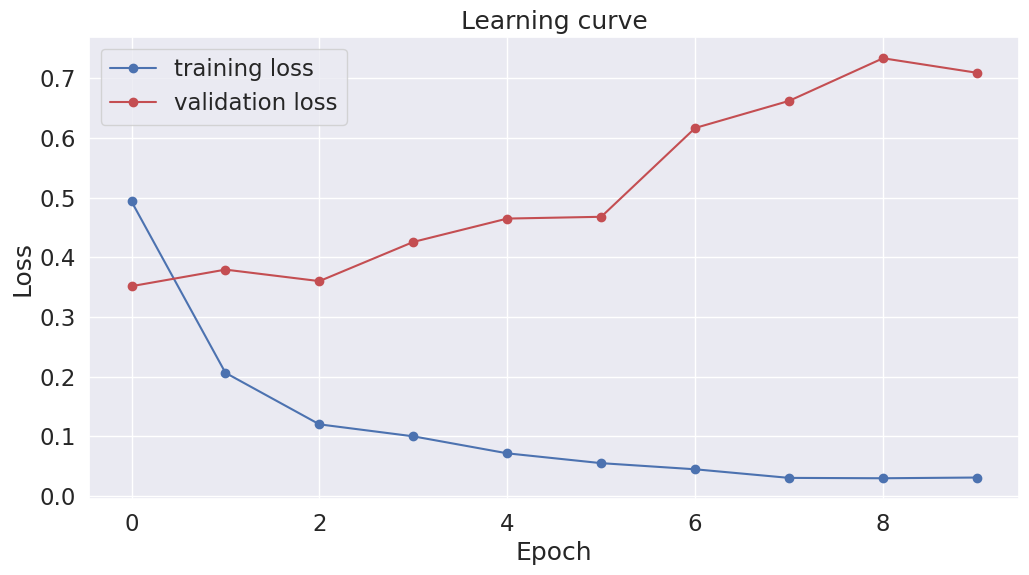

In [11]:
# Use plot styling from seaborn.
sns.set(style='darkgrid')

# Increase the plot size and font size.
sns.set(font_scale=1.5)
plt.rcParams["figure.figsize"] = (12,6)

# Plot the learning curve.
plt.plot(results["loss_values"], 'b-o', label="training loss")
plt.plot(results["development_loss_values"], 'r-o', label="validation loss")

# Label the plot.
plt.title("Learning curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

### **Eval model**

In [10]:
print("1.1. Creating NER data // Test data")
# dict_data_test = read_txt_list(ctx.paths.data_input / "E3C/test")
dict_data_test = read_txt_list(ctx.paths.data_input / "E3C/test")
df_data_test = pd.DataFrame(list(dict_data_test.items()), columns=["archivo_origen", "Text"])

# dict_ann_test = read_ann_list(ctx.paths.data_input / "E3C/test")
dict_ann_test = read_ann_list(ctx.paths.data_input / "E3C/test")
df_ann_test = pd.DataFrame([{"archivo_origen": file_name, **ann_data}for file_name, ann_data in dict_ann_test.items()])
# df_ann = None

data_prepared_test, all_window_labels_test, file_names_test = prepare_data_SYNC(df_data_test, data_ann=df_ann_test, padding=True, tokenizer=tokenizer_ner, model=model_ner, device=ctx.device)

1.1. Creating NER data // Test data


Preparing data for NER prediction: Window slicing and overlapping tokens:   0%|          | 0/17 [00:00<?, ?tex…

In [11]:
id2label = read_json_single(ctx.paths.docs_dir / "NERTraining/Span/E3C/id2label_span_nerclassifier.json")
label2id = read_json_single(ctx.paths.docs_dir / "NERTraining/Span/E3C/label2id_span_nerclassifier.json")
id2label = {int(k): v for k, v in id2label.items()}
label2id = {v: int(k)  for k, v in id2label.items()}

dataset_full_test, data_loader_full_test, _, _ = construct_loaders_ner_SYNC(data_prepared_test, all_window_labels_test, file_names_test, ner_type="span", label2id=label2id, id2label=id2label, seed=SEED, ignore_o_labels=True, batch_size=1)

config.modelo_ner[0] = initialize_span_ner_model(ctx, model_ner, len(id2label), id2label, label2id, tokenizer_ner, "NERTraining/Span/E3C/span_nerclassifier_checkpoint.pt", True)

In [12]:
results = run_span_nerclassifier_SYNC(config.modelo_ner[0], data_loader=data_loader_full_test, device=ctx.device, id2label=id2label, train=False, ignore_o_labels=True)

Span NER / Inference:   0%|          | 0/17 [00:00<?, ?batch/s]


Classification report:
              precision    recall  f1-score   support

        DISO     0.7701    0.8754    0.8193       658
        Date     0.7206    0.7840    0.7510       125
        LIVB     0.9509    0.9509    0.9509       224

   micro avg     0.8005    0.8808    0.8388      1007
   macro avg     0.8138    0.8701    0.8404      1007
weighted avg     0.8041    0.8808    0.8401      1007



## **Results to .ann format**

In [13]:
from SARVI.services.common.utils.ann_utils import ner_outputs_to_ann
from SARVI.data_io.writing import write_ann_list

In [14]:
ann_format = ner_outputs_to_ann(results, id2label, data_loader=data_loader_full_test, original_texts=df_data_test, tokenizer=tokenizer_ner)
# write_ann_list(ctx, ann_format, ctx.paths.data_intermediate / ctx.folder_and_archive_name / "span", extra="")
write_ann_list(ctx, ann_format, ctx.paths.data_intermediate / "E3C/test" / "span", extra="")

## **NER results**

In [15]:
from SARVI.services.common.ner_funcs import classification_report_ner

In [16]:
# dict_ann_test_true = read_ann_list(ctx.paths.data_input / "E3C/test")
dict_ann_test_true = read_ann_list(ctx.paths.data_input / "E3C/test")
df_ann_test_true = pd.DataFrame([{"archivo_origen": file_name, **ann_data}for file_name, ann_data in dict_ann_test_true.items()])

# dict_ann_test_pred = read_ann_list(ctx.paths.data_intermediate / ctx.folder_and_archive_name / "span")
dict_ann_test_pred = read_ann_list(ctx.paths.data_intermediate / "E3C/test" / "span")
df_ann_test_pred = pd.DataFrame([{"archivo_origen": file_name, **ann_data}for file_name, ann_data in dict_ann_test_pred.items()])

label2id = read_json_single(ctx.paths.docs_dir / "NERTraining/Span/E3C/label2id_span_nerclassifier.json")

In [17]:
results = classification_report_ner(df_ann_test_true, df_ann_test_pred, [k for k in label2id.keys() if k != "O"])

              precision    recall  f1-score   support   type_1   type_2   type_3   type_4   type_5

        DISO     0.1139    0.4143    0.1787       251      658        1        0        0      146
        Date     0.0256    0.0566    0.0353        53       68        1        0        3       46
        LIVB     0.1207    0.2258    0.1573        62       56        0        2        1       45

   micro avg     0.1056    0.3306    0.1601       366      782        2        2        4      237
   macro avg     0.0867    0.2323    0.1238       366      782        2        2        4      237
weighted avg     0.1023    0.3306    0.1543       366      782        2        2        4      237
